# 02 - Subgroup analyses and regression

Compares loneliness and mental health across identity groups (sexual orientation, 
race), examines campus belonging and stigma as protective and risk factors, and 
fits multivariate regression models predicting depression and anxiety from 
loneliness controlling for identity, belonging, and stigma.

**Input:** `data/emerging_adults_clean.csv` (produced by `00_clean_data.ipynb`)

**Outputs:**
- `output/loneliness_by_sexual_orientation.png`
- `output/loneliness_by_race.png`
- `output/mental_health_by_belonging.png`
- `output/loneliness_by_perceived_stigma.png`
- `output/regression_depression.csv` — coefficients from the depression model
- `output/regression_anxiety.csv` — coefficients from the anxiety model
- Printed text in the notebook: group means by subgroup, effect sizes (Cohen's d), 
  and regression R-squared and coefficient interpretations

## Setup and data loading

Imports and loads `emerging_adults_clean.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

emerging_adults = pd.read_csv("../data/emerging_adults_clean.csv")

## Loneliness by sexual orientation

My research question asks how loneliness relates to mental health, but the 
relationship may not affect all students equally. Sexual minority students face 
identity-specific stressors — discrimination, stigma, concealment — that elevate 
both loneliness and depression risk. Following Meyer's (2003) minority stress 
theory, I expect higher loneliness among sexual minority students.

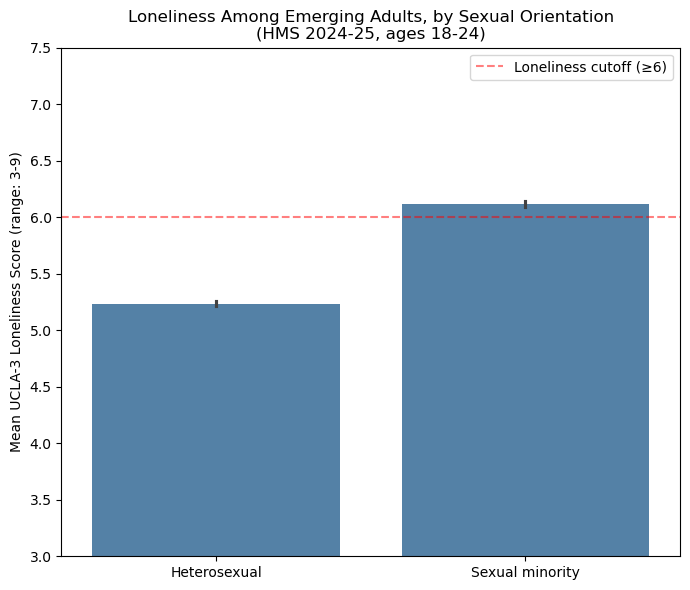

In [2]:
# plot loneliness by binary sexual minority status
plt.figure(figsize=(7, 6))
sns.barplot(data=emerging_adults, x="sexual_orientation_binary", y="lonesc",
            order=["Heterosexual", "Sexual minority"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness Among Emerging Adults, by Sexual Orientation\n(HMS 2024-25, ages 18-24)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (range: 3-9)")
plt.ylim(3, 7.5)
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_sexual_minority_status.png", dpi=150, bbox_inches="tight")
plt.show()

### Loneliness across detailed sexual orientation categories

The binary contrast shows sexual minorities collectively have higher loneliness, 
but doesn't reveal *which* groups are most affected. Disaggregating into nine 
categories reveals the pattern within.

In [3]:
loneliness_by_orient = (emerging_adults.groupby("sexual_orientation")["lonesc"]
                        .agg(["mean", "median", "count"])
                        .round(2)
                        .sort_values("mean"))
print(loneliness_by_orient)

                    mean  median  count
sexual_orientation                     
Heterosexual        5.23     5.0  32373
Self-described      5.52     6.0    588
Gay                 5.96     6.0   1125
Lesbian             5.99     6.0   2055
Asexual             6.02     6.0   1179
Bisexual            6.08     6.0   8438
Questioning         6.24     6.0   1116
Queer               6.30     6.0   1984
Pansexual           6.40     6.0   1610


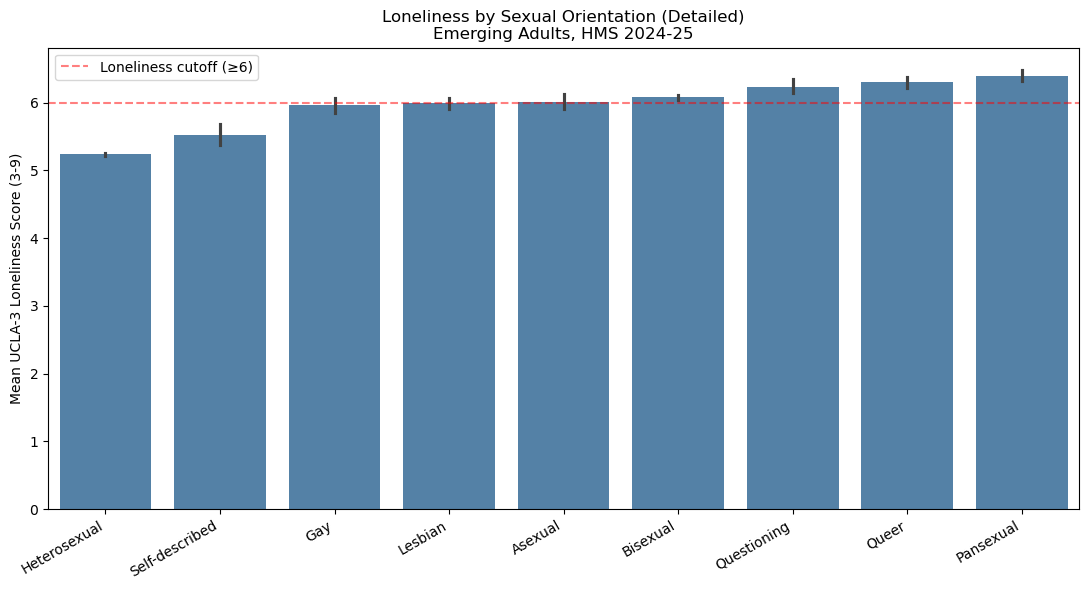

In [4]:
orientation_order = loneliness_by_orient.index.tolist()

plt.figure(figsize=(11, 6))
sns.barplot(data=emerging_adults, x="sexual_orientation", y="lonesc",
            order=orientation_order, color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Sexual Orientation (Detailed)\nEmerging Adults, HMS 2024-25")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_sexual_orientation_detailed.png", dpi=150, bbox_inches="tight")
plt.show()

## Loneliness by race

If loneliness is unequally distributed by race, the burden of any loneliness–
mental-health link will fall unevenly across racial groups. Following research 
on racial minority students' campus experiences, I expect elevated loneliness 
among racial minority students relative to white peers.

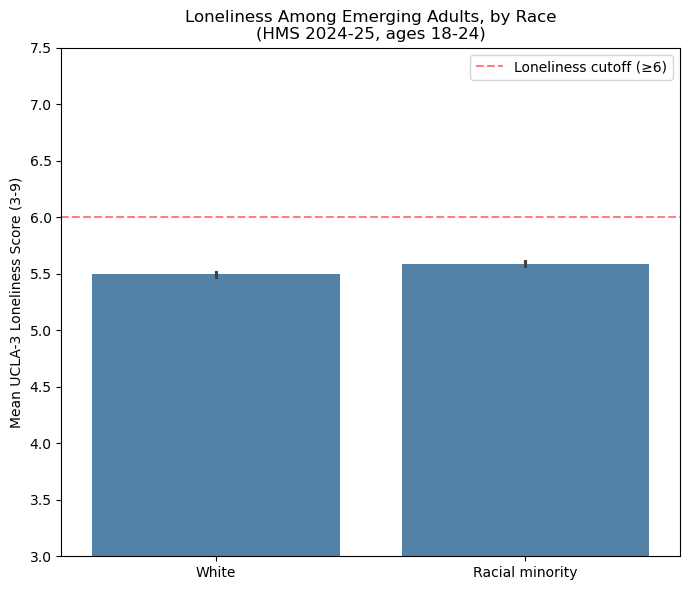

In [5]:
plt.figure(figsize=(7, 6))
sns.barplot(data=emerging_adults, x="race_status", y="lonesc",
            order=["White", "Racial minority"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness Among Emerging Adults, by Race\n(HMS 2024-25, ages 18-24)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.ylim(3, 7.5)
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_race.png", dpi=150, bbox_inches="tight")
plt.show()

## Belonging as a protective factor

My research question asks not just where loneliness is highest, but also what 
might buffer against it. Campus belonging is a candidate protective factor — 
students who feel connected to their campus may report less loneliness. Bin 
students into belonging tertiles (low, moderate, high) and compare mean 
loneliness across them.

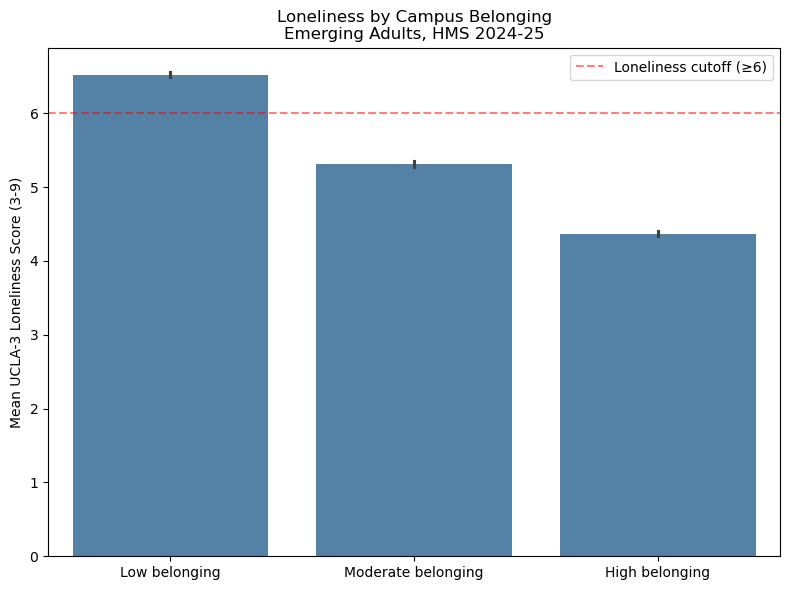

In [6]:
emerging_adults["belong_tertile"] = pd.qcut(
    emerging_adults["belong_total"],
    q=3,
    labels=["Low belonging", "Moderate belonging", "High belonging"]
)

plt.figure(figsize=(8, 6))
sns.barplot(data=emerging_adults, x="belong_tertile", y="lonesc",
            order=["Low belonging", "Moderate belonging", "High belonging"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Campus Belonging\nEmerging Adults, HMS 2024-25")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_belonging.png", dpi=150, bbox_inches="tight")
plt.show()

## Stigma as a risk factor

If belonging is a candidate buffer, perceived stigma is a candidate risk factor. 
Students who think their environment judges mental health negatively may 
experience more isolation, regardless of actual stigma. Compare loneliness 
across perceived stigma tertiles.

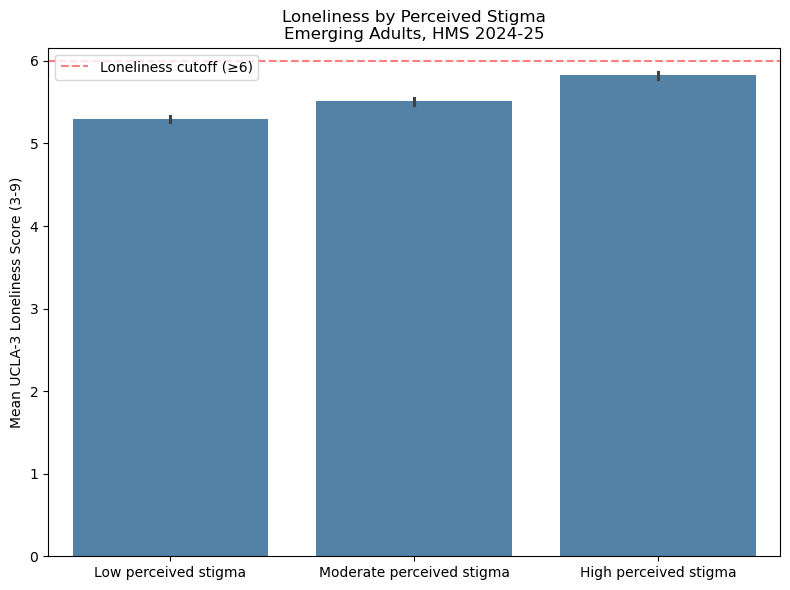

In [7]:
emerging_adults["perceived_stigma_tertile"] = pd.qcut(
    emerging_adults["stigma_perceived"],
    q=3,
    labels=["Low perceived stigma", "Moderate perceived stigma", "High perceived stigma"]
)

plt.figure(figsize=(8, 6))
sns.barplot(data=emerging_adults, x="perceived_stigma_tertile", y="lonesc",
            order=["Low perceived stigma", "Moderate perceived stigma", "High perceived stigma"],
            color="steelblue", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Perceived Stigma\nEmerging Adults, HMS 2024-25")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_perceived_stigma.png", dpi=150, bbox_inches="tight")
plt.show()

## Multivariate regression — depression

The bar charts above show disparities in mean loneliness across groups, but they 
don't tell us whether loneliness still predicts depression after accounting for 
identity and other factors. A regression model with loneliness, belonging, 
stigma, and demographic controls answers that question. Reference categories 
are set to Woman, Heterosexual, and White so coefficients read as comparisons 
to these natural baselines.

In [8]:
# Variables for the regression
model_vars = ["phq9_total", "gad7_total", "lonesc", "belong_total",
              "stigma_self", "stigma_perceived", "age",
              "gender", "sexual_orientation", "race_status"]
model_df = emerging_adults[model_vars].dropna().copy()

print(f"Full emerging adult sample:      {len(emerging_adults):}")
print(f"Complete-case regression sample: {len(model_df):}")
print(f"Dropped due to missing values:   {len(emerging_adults) - len(model_df):}")

Full emerging adult sample:      61288
Complete-case regression sample: 17120
Dropped due to missing values:   44168


In [9]:
# Set explicit reference categories so coefficients are interpretable
gender_order = ["Woman", "Man", "Nonbinary", "Genderqueer", "Trans", "Self-described"]
model_df["gender"] = pd.Categorical(model_df["gender"], categories=gender_order, ordered=False)

orientation_order = ["Heterosexual", "Lesbian", "Gay", "Bisexual", "Pansexual",
                     "Queer", "Questioning", "Asexual", "Self-described"]
model_df["sexual_orientation"] = pd.Categorical(
    model_df["sexual_orientation"], categories=orientation_order, ordered=False)

race_order = ["White", "Racial minority"]
model_df["race_status"] = pd.Categorical(model_df["race_status"], categories=race_order, ordered=False)

# Encode dummies, dropping the reference (first) category
model_encoded = pd.get_dummies(
    model_df,
    columns=["gender", "sexual_orientation", "race_status"],
    drop_first=True
)
# Force booleans to 0/1
model_encoded = model_encoded.astype(
    {col: int for col in model_encoded.columns if model_encoded[col].dtype == bool})

In [10]:
y_dep = model_encoded["phq9_total"]
X = model_encoded.drop(columns=["phq9_total", "gad7_total"])

model_dep = LinearRegression().fit(X, y_dep)

coefs_dep = pd.DataFrame({
    "predictor": X.columns,
    "coefficient": model_dep.coef_.round(3)
}).sort_values("coefficient", key=abs, ascending=False)

print(f"=== DEPRESSION (PHQ-9) MODEL ===")
print(f"Reference groups: Woman, Heterosexual, White")
print(f"R-squared: {model_dep.score(X, y_dep):.3f}")
print(f"Intercept: {model_dep.intercept_:.3f}\n")
print(coefs_dep.to_string(index=False))

coefs_dep.to_csv("../output/regression_depression.csv", index=False)

=== DEPRESSION (PHQ-9) MODEL ===
Reference groups: Woman, Heterosexual, White
R-squared: 0.360
Intercept: 2.459

                        predictor  coefficient
     sexual_orientation_Pansexual        2.512
         sexual_orientation_Queer        1.968
      sexual_orientation_Bisexual        1.639
       sexual_orientation_Lesbian        1.605
                     gender_Trans        1.265
                           lonesc        1.259
            gender_Self-described        1.241
           sexual_orientation_Gay        1.233
   sexual_orientation_Questioning        1.178
sexual_orientation_Self-described        1.021
                 gender_Nonbinary        0.988
                       gender_Man       -0.970
       sexual_orientation_Asexual        0.928
               gender_Genderqueer        0.654
      race_status_Racial minority        0.509
                     belong_total       -0.262
                      stigma_self        0.164
                 stigma_perceived        

## Multivariate regression — anxiety

The same predictors, predicting GAD-7 anxiety instead of PHQ-9 depression. 
Running both models confirms whether the loneliness–mental-health pattern 
generalizes across both common mental health outcomes.

In [11]:
y_anx = model_encoded["gad7_total"]

model_anx = LinearRegression().fit(X, y_anx)

coefs_anx = pd.DataFrame({
    "predictor": X.columns,
    "coefficient": model_anx.coef_.round(3)
}).sort_values("coefficient", key=abs, ascending=False)

print(f"=== ANXIETY (GAD-7) MODEL ===")
print(f"Reference groups: Woman, Heterosexual, White")
print(f"R-squared: {model_anx.score(X, y_anx):.3f}")
print(f"Intercept: {model_anx.intercept_:.3f}\n")
print(coefs_anx.to_string(index=False))

coefs_anx.to_csv("../output/regression_anxiety.csv", index=False)

=== ANXIETY (GAD-7) MODEL ===
Reference groups: Woman, Heterosexual, White
R-squared: 0.285
Intercept: 1.134

                        predictor  coefficient
                       gender_Man       -2.149
     sexual_orientation_Pansexual        1.970
         sexual_orientation_Queer        1.616
           sexual_orientation_Gay        1.532
       sexual_orientation_Lesbian        1.346
      sexual_orientation_Bisexual        1.343
                           lonesc        1.088
   sexual_orientation_Questioning        1.081
            gender_Self-described       -0.839
                     gender_Trans       -0.481
      race_status_Racial minority       -0.273
               gender_Genderqueer       -0.201
       sexual_orientation_Asexual        0.167
                     belong_total       -0.163
                 stigma_perceived        0.101
                              age        0.087
                      stigma_self        0.085
                 gender_Nonbinary        0.0